# Outliers univariantes (Z-score, IQR, boxplots)

**Índice**
1. Outliers del importe: boxplots, Z-score e IQR
2. Outliers en otras variables

## Conexión y carga

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect

AZUL = "#2b6cb0"
AZULES = "Blues_r"
CLASES = {"normal": "#9ecae1", "fraude": "#08306b"}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

client = clickhouse_connect.get_client(host="localhost", port=8123, username="default",
                                       password="password", database="fraude_pagos")

df = client.query_df("SELECT * FROM features_transaccion")
df["clase"] = df["es_fraude"].map({1: "fraude", 0: "normal"})
TOTAL_FRAUDE = int(df["es_fraude"].sum())
print(f"{len(df):,} transacciones, {TOTAL_FRAUDE} fraudulentas ({df['es_fraude'].mean() * 100:.2f} %)")

def evaluar(marcadas, nombre):
    n = int(marcadas.sum())
    vp = int((marcadas & (df["es_fraude"] == 1)).sum())
    return {"método": nombre, "marcadas": n, "% del total": n / len(df) * 100,
            "fraude detectado": vp, "precisión %": vp / n * 100 if n else 0,
            "recall %": vp / TOTAL_FRAUDE * 100}

39,742 transacciones, 715 fraudulentas (1.80 %)


## 1. Outliers univariantes del importe

### 1.1 Boxplots

Un boxplot marca como outliers los puntos fuera de los bigotes. A la izquierda, la cantidad tal cual. A la derecha, en escala logarítmica. Como el importe es muy asimétrico, en escala lineal casi todo queda aplastado abajo y cientos de transacciones normales salen como outliers.

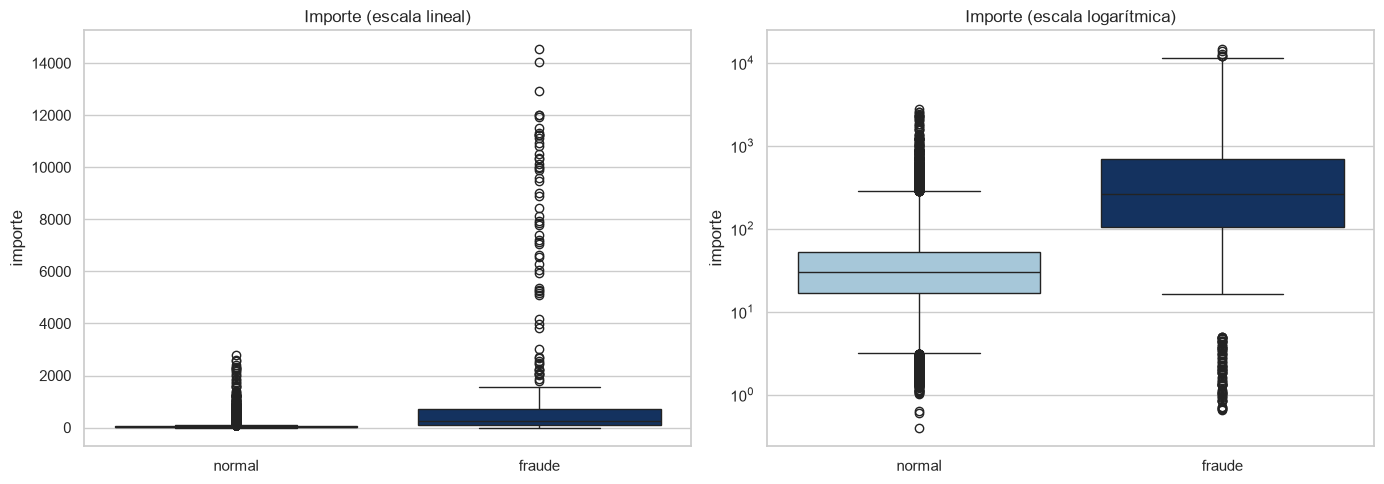

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Importe (escala lineal)")
axes[0].set_xlabel("")
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, log_scale=True, ax=axes[1])
axes[1].set_title("Importe (escala logarítmica)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### 1.2 Z-score e IQR

- Z-score global: |z| > 3, con z = (importe − media) / desviación. Asume una distribución normal.
- Z-score global sobre log(importe): lo mismo, pero sobre el logaritmo, que es mucho más simétrico.
- IQR global: fuera de [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. No asume normalidad.
- IQR global sobre log(importe).
- Z-score por cliente (z_importe_cliente > 3): compara el importe con el historial de ese cliente, usando solo sus compras anteriores.

Precisión: de las transacciones marcadas, qué % es fraude. 
Recall: del fraude total, qué % se marca.

In [8]:
def z_score(x):
    return (x - x.mean()) / x.std()

def fuera_iqr(x, k=1.5):
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (x < q1 - k * iqr) | (x > q3 + k * iqr)

metodos = {
    "Z-score global": z_score(df["importe"]).abs() > 3,
    "Z-score global (log)": z_score(df["log_importe"]).abs() > 3,
    "IQR global": fuera_iqr(df["importe"]),
    "IQR global (log)": fuera_iqr(df["log_importe"]),
    "Z-score por cliente": df["z_importe_cliente"] > 3,
}
comparativa = pd.DataFrame([evaluar(m, nombre) for nombre, m in metodos.items()])

q1, q3 = df["importe"].quantile([0.25, 0.75])
print(f"Media: {df['importe'].mean():.2f} €   Desviación: {df['importe'].std():.2f} €   "
      f"-> umbral Z-score: {df['importe'].mean() + 3 * df['importe'].std():.2f} €")
print(f"Q1: {q1:.2f} €   Q3: {q3:.2f} €   IQR: {q3 - q1:.2f} €   -> umbral IQR: {q3 + 1.5 * (q3 - q1):.2f} €\n")
comparativa.round(1)

Media: 62.02 €   Desviación: 332.04 €   -> umbral Z-score: 1058.13 €
Q1: 17.07 €   Q3: 53.90 €   IQR: 36.83 €   -> umbral IQR: 109.14 €



,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,Z-score global,113,0.3,74,65.5,10.3
1,Z-score global (log),393,1.0,229,58.3,32.0
2,IQR global,3005,7.6,528,17.6,73.8
3,IQR global (log),897,2.3,376,41.9,52.6
4,Z-score por cliente,563,1.4,185,32.9,25.9


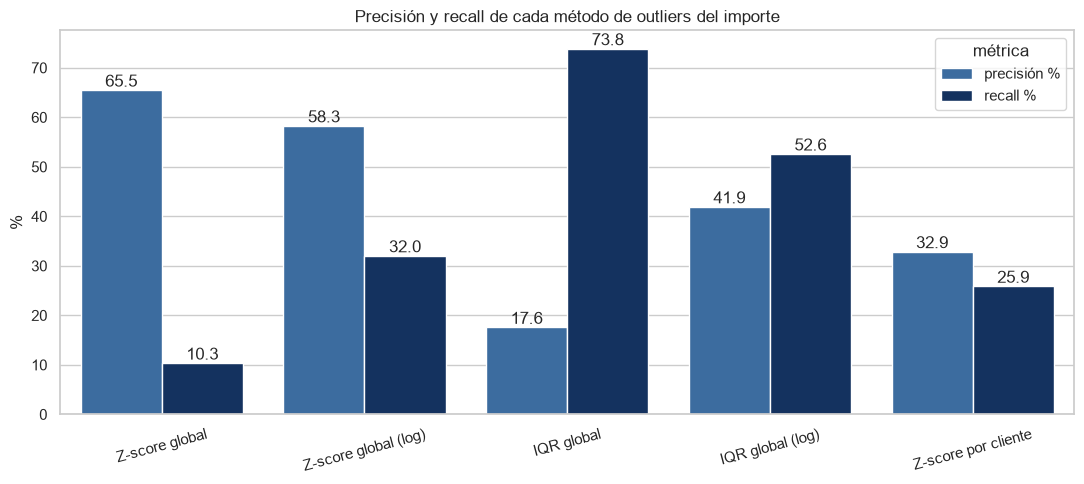

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
comp_larga = comparativa.melt(id_vars="método", value_vars=["precisión %", "recall %"],
                              var_name="métrica", value_name="valor")
sns.barplot(data=comp_larga, x="método", y="valor", hue="métrica",
            palette=[AZUL, "#08306b"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Precisión y recall de cada método de outliers del importe")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

Z-score global: Tiene una precisión alta (65.5 %), pero un recall muy bajo (10.3 %), dejando escapar la gran mayoría del fraude.   

IQR global: Logra el mayor recall (73.8 %), pero su precisión cae drásticamente al 17.6 %, lo que genera demasiadas falsas alarmas.   

Balance: Los métodos basados en escala logarítmica (como el IQR global log con 41.9 % de precisión y 52.6 % de recall) ofrecen un equilibrio mucho más sensato para detectar fraudes de forma eficiente

### 1.3 ¿Qué tipos de fraude detecta cada método?

Porcentaje de las transacciones de cada tipo de fraude que marca cada método. Un método de outliers del importe solo puede detectar los fraudes con importes raros.

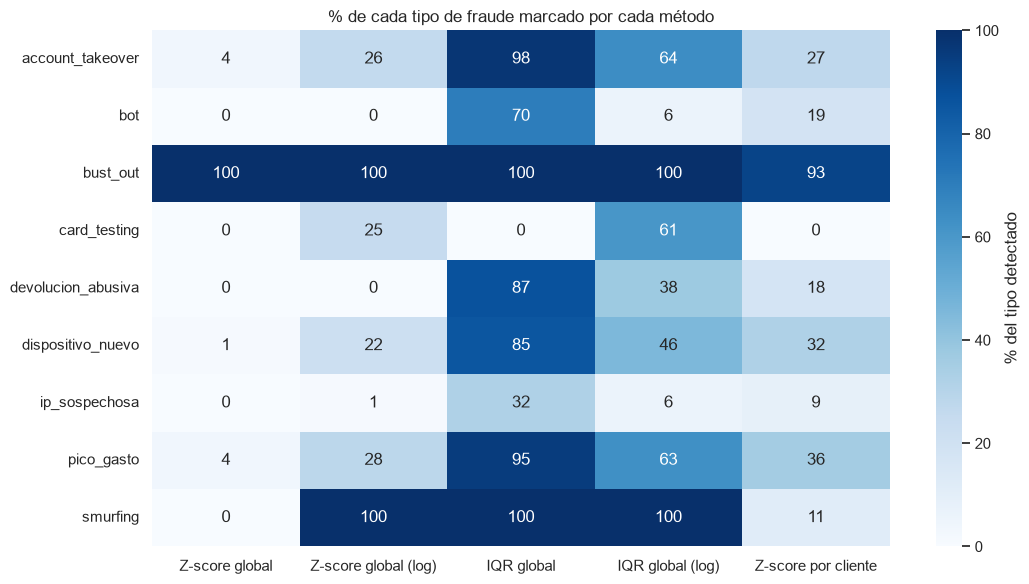

In [10]:
fraude = df[df["es_fraude"] == 1]
por_tipo = pd.DataFrame({nombre: m[fraude.index].groupby(fraude["tipo_fraude"]).mean() * 100
                         for nombre, m in metodos.items()})
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(por_tipo, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% del tipo detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude marcado por cada método")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Los métodos globales detectan bien el bust-out y el smurfing (importes muy altos). 

El card testing (importes de unos 2 €) solo lo detectan los métodos sobre el logaritmo, porque en escala logarítmica los importes muy pequeños 

La IP sospechosa casi no se detecta con ningún método, porque sus importes son normales

## 2. Outliers en otras variables

Boxplots de otras variables numéricas por clase. Las variables de conteo (pagos en 10 min, eventos por sesión...) tienen casi siempre el mismo valor, así que la caja se reduce a una línea y cualquier valor distinto sale como outlier. 

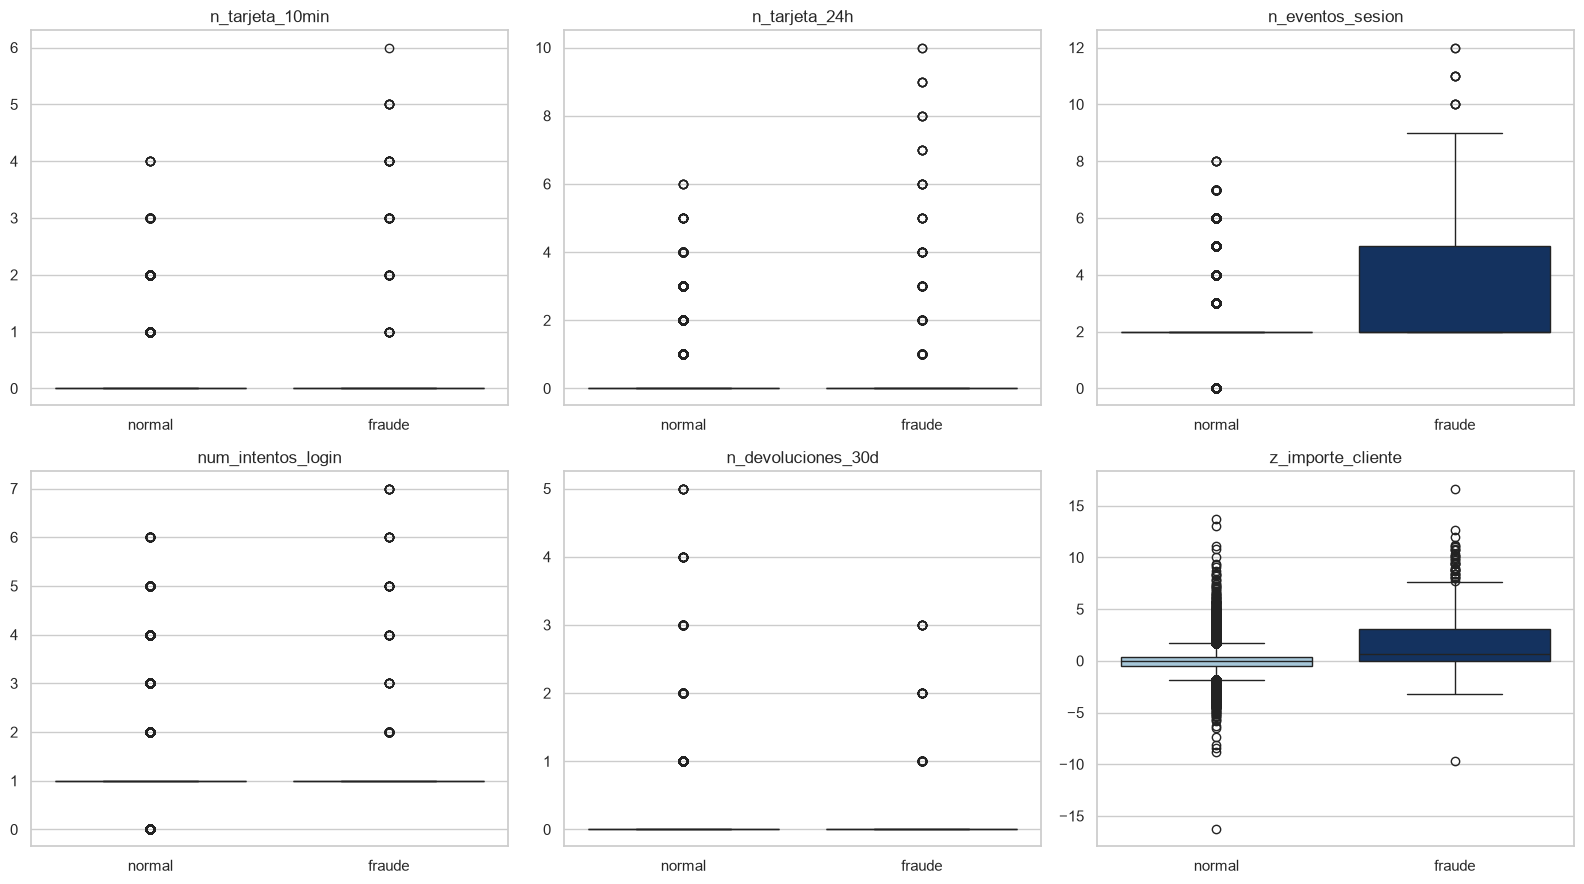

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,IQR n_tarjeta_10min,1406,3.5,69,4.9,9.7
1,IQR n_tarjeta_24h,6739,17.0,157,2.3,22.0
2,IQR n_eventos_sesion,15249,38.4,270,1.8,37.8
3,IQR num_intentos_login,12732,32.0,110,0.9,15.4
4,IQR n_devoluciones_30d,2100,5.3,64,3.0,9.0
5,IQR z_importe_cliente,3265,8.2,295,9.0,41.3


In [11]:
VARIABLES = ["n_tarjeta_10min", "n_tarjeta_24h", "n_eventos_sesion", "num_intentos_login",
             "n_devoluciones_30d", "z_importe_cliente"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var in zip(axes.flat, VARIABLES):
    sns.boxplot(data=df, x="clase", y=var, hue="clase", order=["normal", "fraude"],
                palette=CLASES, legend=False, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

iqr_otras = pd.DataFrame([evaluar(fuera_iqr(df[v]), f"IQR {v}") for v in VARIABLES])
iqr_otras.round(1)

Variables de conteo: Al concentrarse la gran mayoría de los datos en valores de 0 o 1, cualquier acción repetida o inusual salta de inmediato como outlier.   

Capacidad de detección: Variables como n_eventos_sesion logran capturar hasta un 37.8 % del fraude total, demostrando que analizar el comportamiento del usuario complementa muy bien a los filtros basados únicamente en el dinero.   

Ningún método univariante basta. El más equilibrado (IQR sobre el logaritmo) detecta el 52,6 % del fraude con un 41,9 % de precisión: o se detecta poco, o se dan muchas falsas alarmas.


El IQR es más robusto que el Z-score, porque no asume normalidad, pero sobre el importe tal cual marca el 7,6 % de todas las transacciones.


El IQR no sirve para variables de conteo, porque cualquier valor distinto del habitual sale como outlier.

Los outliers no se eliminan en detección de fraude son justo los casos que interesan.